<a href="https://colab.research.google.com/github/Maniganiga404/Experiments/blob/main/AMLlab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

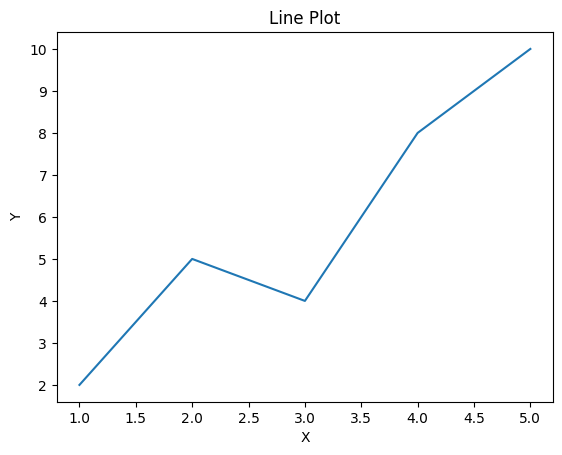

In [26]:
#Matplotlib
import matplotlib.pyplot as plt

x=[1,2,3,4,5]
y=[2,5,4,8,10]

plt.plot(x,y)
plt.title("Line Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [27]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

df = iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


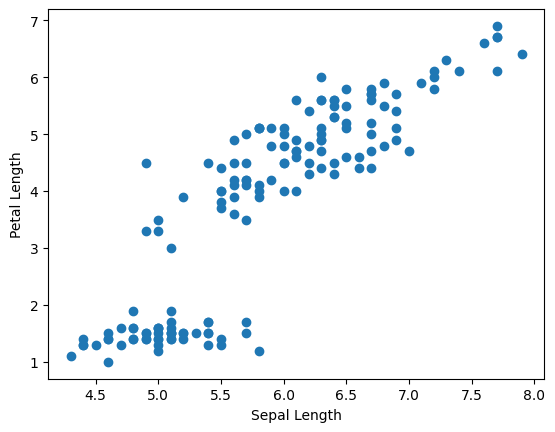

In [28]:
plt.scatter(df['sepal length (cm)'],
            df['petal length (cm)'])

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

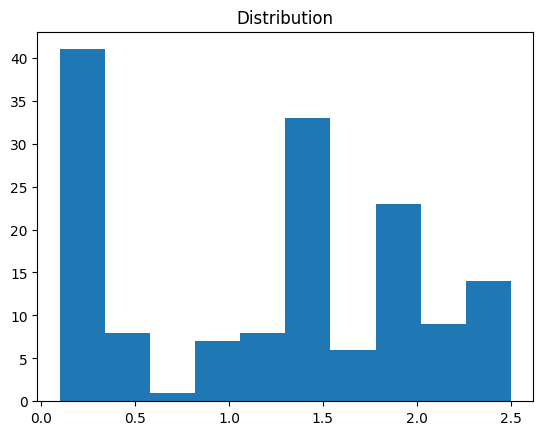

In [29]:
#Activity 3
plt.hist(df['petal width (cm)'])

plt.title("Distribution")
plt.show()

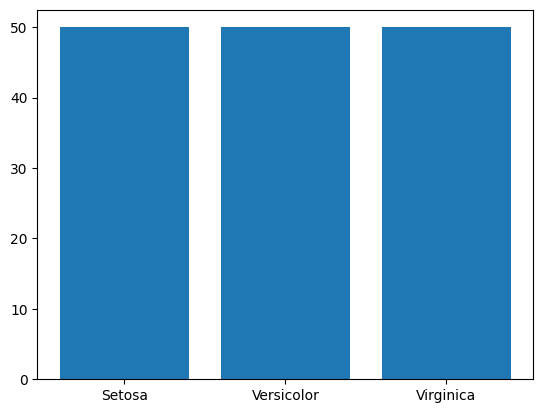

In [30]:
#Activity 4
species = ['Setosa','Versicolor','Virginica']

count = df['target'].value_counts()

plt.bar(species,count)

plt.show()

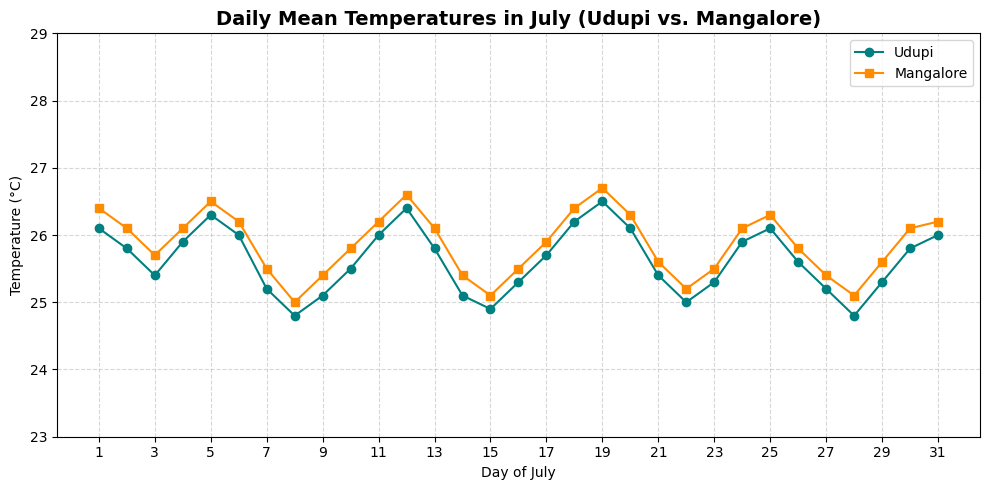

In [31]:
#Assignment
#Plot temperature of two cities in same graph of july month with line plot,two lines should be of different legends(colors)

import matplotlib.pyplot as plt

days = list(range(1,32));

udupi_temps = [26.1, 25.8, 25.4, 25.9, 26.3, 26.0, 25.2, 24.8, 25.1, 25.5,
               26.0, 26.4, 25.8, 25.1, 24.9, 25.3, 25.7, 26.2, 26.5, 26.1,
               25.4, 25.0, 25.3, 25.9, 26.1, 25.6, 25.2, 24.8, 25.3, 25.8, 26.0]

mangalore_temps = [26.4, 26.1, 25.7, 26.1, 26.5, 26.2, 25.5, 25.0, 25.4, 25.8,
                   26.2, 26.6, 26.1, 25.4, 25.1, 25.5, 25.9, 26.4, 26.7, 26.3,
                   25.6, 25.2, 25.5, 26.1, 26.3, 25.8, 25.4, 25.1, 25.6, 26.1, 26.2]

# Create line plot
plt.figure(figsize=(10, 5))
plt.plot(days, udupi_temps, color='teal', marker='o', label='Udupi')
plt.plot(days, mangalore_temps, color='darkorange', marker='s', label='Mangalore')

# Annotations & Styling
plt.title('Daily Mean Temperatures in July (Udupi vs. Mangalore)', fontsize=14, fontweight='bold')
plt.xlabel('Day of July')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 32, 2))
plt.ylim(23, 29)  # Adjusted window for clear visual comparison
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Display
plt.tight_layout()
plt.show()


In [32]:
#SciKit
from sklearn.datasets import load_iris

iris = load_iris()

x = iris.data
y = iris.target

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train,y_train)


DecisionTreeClassifier()

In [35]:
pred = model.predict(X_test)
print(pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [36]:
from sklearn.metrics import(
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
#Evaluation
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='weighted'))
print("Recall:", recall_score(y_test, pred, average='weighted'))
print("F1 Score:", f1_score(y_test, pred, average='weighted'))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

Accuracy : 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [37]:
from sklearn.model_selection import cross_val_score
# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring='accuracy'
)
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.96666667 0.96666667 0.9        0.96666667 1.        ]
Mean CV Accuracy: 0.9600000000000002


In [38]:
#ASSIGNMENT breast cancer
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
cancer = load_breast_cancer()

x = cancer.data
y = cancer.target

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [40]:
# Split into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [41]:
# Feature Scaling (Highly recommended for Logistic Regression convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
x_scaled = scaler.fit_transform(x)  # Scaled version of full data for CV

In [42]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predict on the test set
pred = model.predict(X_test)
print("Predictions:\n", pred)

Predictions:
 [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# Evaluation
print("\nAccuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='weighted'))
print("Recall   :", recall_score(y_test, pred, average='weighted'))
print("F1 Score :", f1_score(y_test, pred, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))


Accuracy : 0.9736842105263158
Precision: 0.9737190197716513
Recall   : 0.9736842105263158
F1 Score : 0.973621425014614

Confusion Matrix:
[[41  2]
 [ 1 70]]


In [44]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation (Using scaled full features)
cv_scores = cross_val_score(
    model,
    x_scaled,
    y,
    cv=5,
    scoring='accuracy'
)
print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


CV Scores: [0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean CV Accuracy: 0.9806862288464524


In [46]:
#Assignment wine data
from sklearn.datasets import load_wine

# Load the Wine recognition dataset
wine = load_wine()

x = wine.data
y = wine.target


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [48]:
# Split into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [49]:
# Feature Scaling (Mandatory for KNN since it calculates distance metrics)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
x_scaled = scaler.fit_transform(x)  # Scaled version of full data for CV


In [53]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model (Default k=5 neighbors)
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

# Predict on the test set
pred = model.predict(X_test)
print("Predictions:\n", pred)

Predictions:
 [0 0 2 0 1 0 1 2 1 2 0 2 0 2 0 1 1 1 0 1 0 1 1 2 2 2 1 0 1 0 0 1 2 0 0 0]


In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# Ensure pred is updated for the current model and test set
pred = model.predict(X_test)

# Evaluation
print("\nAccuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='weighted'))
print("Recall   :", recall_score(y_test, pred, average='weighted'))
print("F1 Score :", f1_score(y_test, pred, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))


Accuracy : 0.9444444444444444
Precision: 0.9493827160493827
Recall   : 0.9444444444444444
F1 Score : 0.9436036129748098

Confusion Matrix:
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]


In [55]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation (Using scaled full features)
cv_scores = cross_val_score(
    model,
    x_scaled,
    y,
    cv=5,
    scoring='accuracy'
)
print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


CV Scores: [0.94444444 0.94444444 0.97222222 1.         0.91428571]
Mean CV Accuracy: 0.9550793650793651
